In [1]:
import pandas as pd
import os
from pathlib import Path

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm.notebook import tqdm
import fastcluster

In [2]:
root = Path("/home/shares/schaerm/schaer2/thibaut/humanlisbet/output/trained_models/real_train/tr/models/lisbet-tr-121225-embedder/embeddings")
train = root / "train"
test = root / "test"
out = root / "hierarchy_clustering"
out.mkdir(exist_ok=True)

In [13]:
segs = []
names = []
for i, folder in enumerate(train.iterdir()):
    if folder.is_dir():
        segs.append(pd.read_csv(folder / "features_lisbet_embedding.csv", index_col=0).to_numpy())
        names.append(folder.name)
    if i > 10:
        break

segs_test = []
names_test = []

for i, folder in enumerate(test.iterdir()):
    if folder.is_dir():
        # segs_test.append(pd.read_csv(folder / "features_lisbet_embedding.csv", index_col=0).to_numpy())
        names_test.append(folder.name)
    # if i > 10:
    #     break


In [9]:
def exponential_smoothing(X, alpha=0.3):
    """
    Apply exponential smoothing along time axis.
    
    Parameters:
    -----------
    data : pd.DataFrame or np.ndarray
        Input data where rows are time steps
    alpha : float (0 < alpha <= 1)
        Smoothing factor. Lower values = more smoothing
        Higher values (closer to 1) = preserve sharp changes better
        
    Returns:
    --------
    smoothed : np.ndarray
        Smoothed data with same shape as input
    """
    X = np.asarray(X, dtype=np.float32)

    fwd = np.zeros_like(X)
    bwd = np.zeros_like(X)

    fwd[0] = X[0]
    for t in range(1, len(X)):
        fwd[t] = alpha * X[t] + (1 - alpha) * fwd[t-1]

    bwd[-1] = X[-1]
    for t in range(len(X)-2, -1, -1):
        bwd[t] = alpha * X[t] + (1 - alpha) * bwd[t+1]

    return 0.5 * (fwd + bwd)



In [12]:
segs

[]

In [11]:
# Test smoothing:

def temporal_energy(X):
    return np.mean(np.linalg.norm(np.diff(X, axis=0), axis=1))

de = pd.DataFrame(columns=["alpha", "temporal_energy", "ratio"])

X = segs[np.random.randint(len(segs))]

print(f"Raw :", temporal_energy(X))
de = pd.concat([de, pd.DataFrame([{"alpha": 0.0, "temporal_energy": temporal_energy(X), "ratio": 1.0}])], ignore_index=True)

for alph in range(1, 10):
    alph = alph / 10.0
    smoothed = exponential_smoothing(X, alpha=alph)
    print(f"α={alph:.1f} : {temporal_energy(smoothed):.3f}, ratio: {temporal_energy(smoothed)/temporal_energy(X):.3f}")
    de = pd.concat([de, pd.DataFrame([{"alpha": alph, "temporal_energy": temporal_energy(smoothed), "ratio": temporal_energy(smoothed)/temporal_energy(X)}])], ignore_index=True)
de.to_csv(out / "temporal_smoothing_analysis.csv", index=False)
# For bhv we want 0.5<ratio<0.7


ValueError: high <= 0

In [14]:
# Apply exponential smoothing to each segment
segs_smoothed = []
for i, seg in enumerate(segs):
    smoothed = exponential_smoothing(seg, alpha=0.7)
    smoothed_df = pd.DataFrame(smoothed)
    smoothed_df['segment_name'] = names[i]
    smoothed_df.reset_index(inplace=True)
    segs_smoothed.append(smoothed_df)
    # print(f"Segment {i} smoothed: {smoothed_df.shape}")

# Concatenate all smoothed segments into one dataframe
df = pd.concat(segs_smoothed, axis=0, ignore_index=True)
print(f"\nCombined dataframe shape: {df.shape}")

# Also create a segment label column to track which segment each frame belongs to
segment_labels = []
for i, seg in enumerate(segs_smoothed):
    segment_labels.extend([i] * len(seg))
df['segment_id'] = segment_labels

# print(f"Segment distribution:")
# print(df['segment_id'].value_counts().sort_index())
df.to_csv(out / "train_smoothed_features.csv", index=False)

### test : 

# Apply exponential smoothing to each segment
segs_smoothed_test = []
for i, seg in enumerate(segs_test):
    smoothed = exponential_smoothing(seg, alpha=0.7)
    smoothed_df = pd.DataFrame(smoothed)
    smoothed_df['segment_name'] = names_test[i]
    smoothed_df.reset_index(inplace=True)
    segs_smoothed_test.append(smoothed_df)
    # print(f"Segment {i} smoothed: {smoothed_df.shape}")

# Concatenate all smoothed segments into one dataframe
df_test = pd.concat(segs_smoothed_test, axis=0, ignore_index=True)
print(f"\nCombined dataframe shape: {df_test.shape}")

# Also create a segment label column to track which segment each frame belongs to
segment_labels = []
for i, seg in enumerate(segs_smoothed_test):
    segment_labels.extend([i] * len(seg))
df_test['segment_id'] = segment_labels
df_test.to_csv(out / "test_smoothed_features.csv", index=False)


Combined dataframe shape: (18957, 258)


ValueError: No objects to concatenate

In [14]:
smoothed_df

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,2.960326,0.194155,-0.644011,2.391592,-1.459561,-0.461327,2.223110,-0.251082,-1.005851,0.028382,...,0.154823,2.526934,0.771665,-0.589249,0.563189,1.777693,0.064808,-0.465360,-0.072836,1.911010
1,2.195524,0.529120,-0.464250,2.151469,-1.031411,-0.420747,2.729562,-0.202785,-1.188755,0.179482,...,0.174254,2.870407,0.823319,-0.382484,0.717028,2.720596,-0.017027,-0.426394,-0.183727,2.259333
2,2.055124,0.568264,-0.418992,2.199370,-0.959304,-0.422726,2.754975,-0.174150,-1.205094,0.186922,...,0.117228,2.867650,0.800342,-0.303525,0.752170,2.966435,-0.055967,-0.466646,-0.227896,2.319079
3,2.075548,1.110126,-0.499547,2.337712,-0.919434,-0.590011,2.231947,-0.173791,-1.250382,0.119454,...,-0.081846,2.891953,0.684889,-0.286084,1.003095,3.020720,-0.075237,-0.391641,-0.167219,2.387578
4,2.242308,0.998208,-0.568952,2.503103,-0.886234,-0.573448,1.857514,-0.162212,-1.144951,0.067269,...,-0.175941,2.603509,0.541920,-0.299258,1.157548,2.836940,-0.147423,-0.404969,-0.131990,2.323946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420,0.516676,-2.459536,0.254451,1.422101,0.616590,1.128277,1.158369,-0.067026,-0.499119,-0.837705,...,0.062840,-0.547475,-0.753449,-0.576805,0.540121,-1.159929,-0.767105,-1.524660,0.621892,-0.248695
421,0.695206,-2.289486,0.316362,1.323654,0.489022,1.207882,0.908836,-0.249732,-0.635247,-0.901132,...,-0.189245,-0.514654,-0.678424,-0.589415,0.777539,-1.409687,-0.805480,-1.519244,0.372671,-0.362028
422,0.548138,-2.073296,0.248878,1.318050,0.476580,1.137654,0.697121,-0.317351,-0.634071,-0.747555,...,-0.078977,-0.591309,-0.633601,-0.540902,1.157739,-1.407118,-0.895295,-1.359589,0.314657,-0.464176
423,0.497427,-2.051191,0.195041,1.388636,0.571256,1.082771,0.675172,-0.292747,-0.639239,-0.711932,...,-0.154016,-0.635299,-0.654452,-0.555731,1.145158,-1.398232,-0.901762,-1.345946,0.237252,-0.425302


In [17]:
seg_0_original[100:200, dim]

array([ 0.3928075 ,  0.3762557 ,  0.37045068,  0.36146176,  0.3569668 ,
        0.33928043,  0.32823488,  0.32979617,  0.34148934,  0.3185728 ,
        0.3041051 ,  0.29162428,  0.28566357,  0.2795565 ,  0.27819145,
        0.28079528,  0.27610728,  0.2605525 ,  0.25950003,  0.25490305,
        0.25535136,  0.2526006 ,  0.24607943,  0.23304404,  0.23152877,
        0.2280166 ,  0.24254748,  0.24531837,  0.23073258,  0.2358336 ,
        0.21068113,  0.20643498,  0.2211889 ,  0.24845476,  0.22670378,
        0.23094709,  0.25949004,  0.27735454,  0.24576414,  0.22677208,
        0.2831335 ,  0.28454226,  0.28893855,  0.29554236,  0.31941545,
        0.3818639 ,  0.4024453 , -0.1652366 ,  0.45131725, -0.07040494,
       -0.02070817,  0.04345785,  0.07741122,  0.1620821 ,  0.24728768,
        0.33306065,  0.40390056,  0.5597795 ,  0.645531  ,  0.7525219 ,
        0.8425487 ,  0.51551914,  0.6645577 ,  0.7718448 ,  0.893305  ,
        1.0802755 ,  1.1550884 ,  1.2596779 ,  1.3622057 ,  1.53

In [18]:
seg_0_smoothed.loc[100:200, dim]

100    0.390697
101    0.377558
102    0.370307
103    0.361707
104    0.355081
         ...   
196    1.701960
197    1.689001
198    1.669853
199    1.663280
200    1.669096
Name: 100, Length: 101, dtype: float32

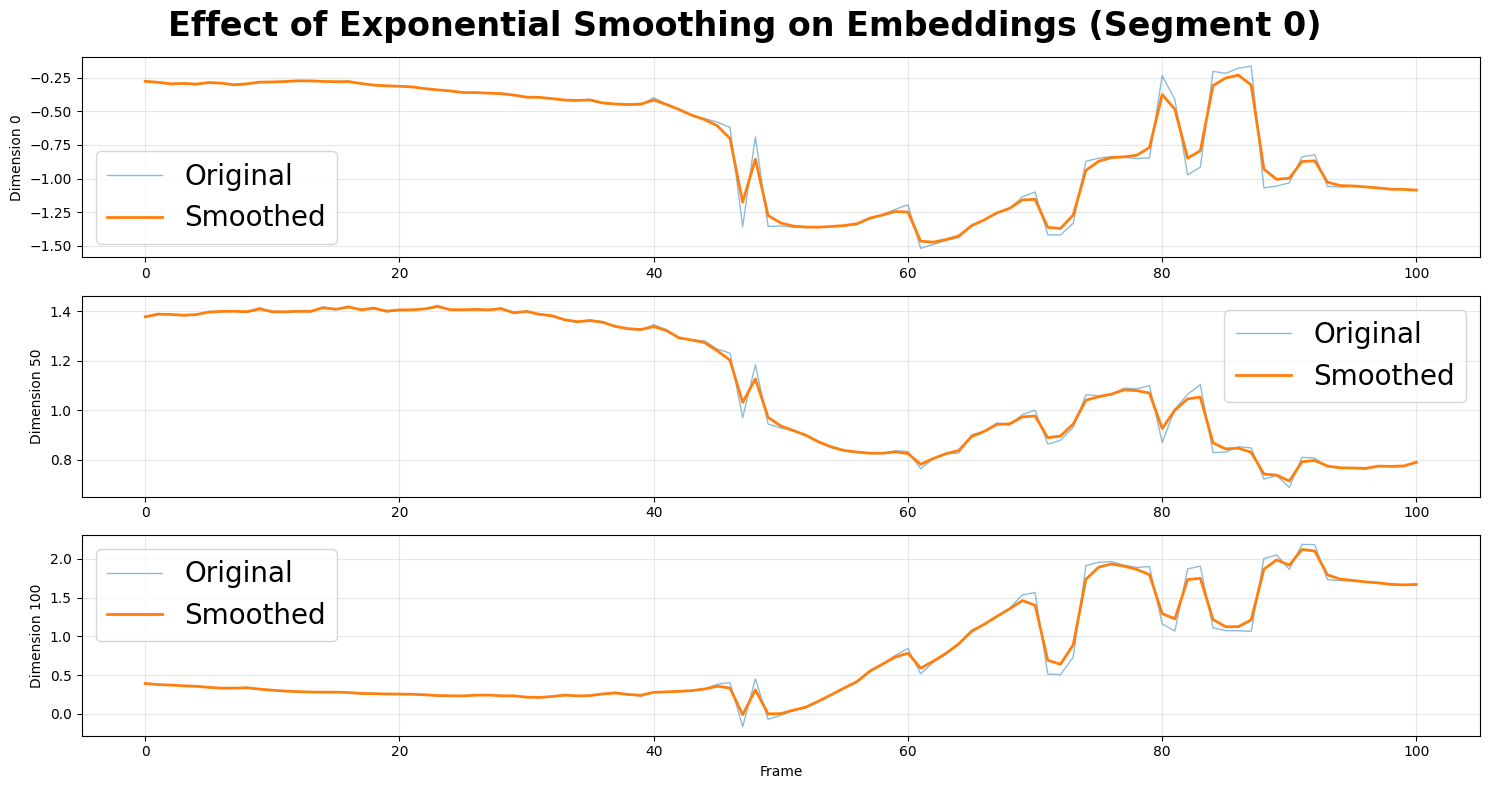

In [24]:
# Visualize the effect of smoothing on a few dimensions from the first segment
seg_0_original = segs[1]
seg_0_smoothed = segs_smoothed[1]

fig, axes = plt.subplots(3, 1, figsize=(15, 8))
dims_to_plot = [0, min(50, seg_0_original.shape[1]-1), min(100, seg_0_original.shape[1]-1)]

for i, dim in enumerate(dims_to_plot):
    axes[i].plot(seg_0_original[100:200, dim], alpha=0.5, label='Original', linewidth=1)
    axes[i].plot(seg_0_smoothed.loc[100:200, dim].to_numpy(), label='Smoothed', linewidth=2)
    axes[i].set_ylabel(f'Dimension {dim}')
    axes[i].legend(fontsize=20)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame')
plt.suptitle('Effect of Exponential Smoothing on Embeddings (Segment 0)', fontsize=24, fontweight='bold')
plt.tight_layout()
plt.savefig(out / "smoothing_effect_segment_0.png")
plt.show()

In [5]:
df = pd.read_csv(out / "train_smoothed_features.csv")

df_test = pd.read_csv(out / "test_smoothed_features.csv")

In [132]:
df

,0,1,2,3,4,5,6,7,8,9,...,247,248,249,250,251,252,253,254,255,segment_id
0,2.912275,-1.586671,-0.563191,1.953273,-1.504419,0.232358,2.862194,-0.084604,-0.869344,-0.135348,...,2.102105,0.867964,-0.646760,0.273038,0.833634,-0.283195,-0.529068,-0.116389,1.688021,0
1,2.813429,-1.609902,-0.637321,1.957148,-1.342056,0.298692,2.730185,-0.015838,-0.747254,-0.125695,...,1.858480,0.847301,-0.507493,0.401676,1.041322,-0.443057,-0.573150,-0.137157,1.682798,0
2,1.392535,-1.999742,-0.025286,1.142155,-0.561598,0.914643,3.710985,-0.048691,-0.969110,0.310808,...,1.667121,1.001594,-0.089485,0.696023,2.622499,-0.929614,-0.787865,-0.317302,1.856823,0
3,1.000328,-1.811827,0.091461,1.063048,-0.335328,0.953911,3.788075,0.077083,-0.924319,0.286874,...,1.725342,1.084634,-0.013091,0.413179,3.142873,-1.000264,-0.927722,-0.262966,2.004759,0
4,0.744612,-0.718734,0.119135,1.128807,-0.336165,0.708012,3.545437,0.117203,-0.915370,0.325139,...,2.048122,1.212707,-0.059483,0.212437,3.883486,-0.997011,-0.915403,0.021915,2.205127,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4862118,-0.950636,-1.413641,0.523271,0.300345,0.411900,0.655083,0.221784,-0.152689,0.282320,-1.178533,...,-0.382607,-1.198141,0.490938,-1.241740,-1.028875,-0.778764,-1.593458,-0.291337,0.019482,2004
4862119,-0.681033,-1.131699,0.389935,0.449659,-0.128521,0.733625,0.351834,-0.218727,-0.540989,-1.426372,...,-0.152841,-1.039942,0.470455,-1.267588,-1.189187,-0.305955,-1.657653,-0.087028,0.011707,2004
4862120,-0.834163,-1.148436,0.312634,0.469243,-0.147113,0.561710,0.430290,-0.165205,-0.575370,-1.370406,...,-0.213608,-1.104281,0.475921,-1.247073,-1.163311,-0.258592,-1.768295,-0.024156,0.133083,2004
4862121,-0.690561,-1.128381,0.074032,0.688623,-0.341609,0.603696,0.431434,-0.312868,-0.615167,-1.320834,...,-0.456975,-0.979308,0.339659,-1.137289,-1.324432,0.124495,-1.619189,0.030244,-0.253530,2004


In [6]:
# Concatenate all segments into a single array
# X = np.vstack([seg.values for seg in segs_smoothed])
X = df.drop(columns=["segment_id", "segment_name"]).values
print(f"Total data shape: {X.shape}")
print(f"Feature dimensionality: {X.shape[1]}")
print(f"Total number of frames: {X.shape[0]}")


# Concatenate all segments into a single array
# X_test = np.vstack([seg.values for seg in segs_smoothed_test])
X_test = df_test.drop(columns=["segment_id", "segment_name"]).values
print(f"Total data shape: {X_test.shape}")
print(f"Feature dimensionality: {X_test.shape[1]}")
print(f"Total number of frames: {X_test.shape[0]}")

Total data shape: (3881230, 257)
Feature dimensionality: 257
Total number of frames: 3881230
Total data shape: (461263, 257)
Feature dimensionality: 257
Total number of frames: 461263


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

np.save(out / "X_scaled.npy", X_scaled)
np.save(out / "X_test_scaled.npy", X_test_scaled)

In [8]:
X_scaled = np.load(out / "X_scaled.npy")
X_test_scaled = np.load(out / "X_test_scaled.npy")

In [9]:
# def inspect_birch_thresholds(X, thresholds):
#     from sklearn.cluster import Birch
#     for t in thresholds:
#         b = Birch(threshold=t, n_clusters=None).fit(X)
#         print(f"threshold={t:.2f} → {len(b.subcluster_centers_)} subclusters")

# inspect_birch_thresholds(
#     X_scaled,
#     thresholds=[i for i in np.arange(0.1, 2.1, 0.1)]
# )

In [10]:
threshold = 9

brc = Birch(threshold=threshold,
            branching_factor=500,
            n_clusters=None,
            compute_labels=False)

# train in batch 
batch_size = 10000
for i in tqdm(range(0, X_scaled.shape[0], batch_size)):
    end = min(i + batch_size, X_scaled.shape[0])
    brc.partial_fit(X_scaled[i:end])

    if i % (10 * batch_size) == 0:
        print(len(brc.subcluster_centers_))



  0%|          | 0/389 [00:00<?, ?it/s]

48
568
1048
1516
2063
2465
3151
3663
4099
4640
5124
5625
5994
6362
6761
7251
7797
8260
8659
9047
9513
9943
10359
10810
11278
11721
12132
12484
12895
13335
13692
14058
14469
14819
15142
15498
15807
16089
16421


In [11]:
import torch
torch.set_grad_enabled(False)
# torch.cuda.synchronize()
# torch.cuda.empty_cache()

def gpu_assign_batched_fast(
    X,
    C,
    batch_size=2048,
    device="cuda"
):
    N, D = X.shape
    labels = torch.empty(N, dtype=torch.int32)

    C_norm = (C ** 2).sum(dim=1).unsqueeze(0)  # (1, M)

    for i in tqdm(range(0, N, batch_size)):
        Xb = torch.tensor(
            X[i:i+batch_size],
            dtype=torch.float32,
            device=device
        ).half()

        X_norm = (Xb ** 2).sum(dim=1).unsqueeze(1)  # (B, 1)

        # Squared distances (B, M)
        dists = X_norm + C_norm - 2 * (Xb @ C.T)

        labels[i:i+batch_size] = torch.argmin(dists, dim=1).cpu()

        del Xb, X_norm, dists
        torch.cuda.empty_cache()

    return labels.numpy()

In [12]:
centroids = brc.subcluster_centers_.astype("float32")
C = torch.tensor(centroids, device="cuda")

In [29]:
X = X_scaled
batch_size = 256

N, D = X.shape
labels = torch.empty(N, dtype=torch.int32)

C_norm = (C ** 2).sum(dim=1).unsqueeze(0)  # (1, M)

for i in tqdm(range(0, N, batch_size)):
    Xb = torch.tensor(
        X[i:i+batch_size],
        dtype=torch.float32,
        device='cuda'
    )

    X_norm = (Xb ** 2).sum(dim=1).unsqueeze(1)  # (B, 1)

    # Squared distances (B, M)
    dists = X_norm + C_norm - 2 * (Xb @ C.T)

    labels[i:i+batch_size] = torch.argmin(dists, dim=1).cpu()

    del Xb, X_norm, dists
    torch.cuda.empty_cache()

  0%|          | 0/15162 [00:00<?, ?it/s]

In [14]:
np.savetxt(out / "birch_cluster_labels.csv", labels.numpy(), delimiter=",", header="cluster_id", comments='', fmt='%d')

In [30]:
X = X_test_scaled
batch_size = 256

N, D = X.shape
labels_test = torch.empty(N, dtype=torch.int32)

C_norm = (C ** 2).sum(dim=1).unsqueeze(0)  # (1, M)

for i in tqdm(range(0, N, batch_size)):
    Xb = torch.tensor(
        X[i:i+batch_size],
        dtype=torch.float32,
        device='cuda'
    )

    X_norm = (Xb ** 2).sum(dim=1).unsqueeze(1)  # (B, 1)

    # Squared distances (B, M)
    dists = X_norm + C_norm - 2 * (Xb @ C.T)

    labels_test[i:i+batch_size] = torch.argmin(dists, dim=1).cpu()

    del Xb, X_norm, dists
    torch.cuda.empty_cache()

  0%|          | 0/1802 [00:00<?, ?it/s]

In [16]:
np.savetxt(out / "test_birch_cluster_labels.csv", labels_test.numpy(), delimiter=",", header="cluster_id", comments='', fmt='%d')

In [17]:
# print("Predicting test cluster labels...")
# test_birch_labels = brc.predict(X_test_scaled)
# np.savetxt(out / "test_birch_cluster_labels.csv", test_birch_labels, delimiter=",", header="cluster_id", comments='', fmt='%d')

In [18]:
# save labels
# pd.DataFrame(birch_labels, columns=["cluster_id"]).to_csv(out / "train_birch_cluster_labels.csv", index=False)
# pd.DataFrame(test_birch_labels, columns=["cluster_id"]).to_csv(out / "test_birch_cluster_labels.csv", index=False)

Number of BIRCH subclusters: 16573


  0%|          | 0/16573 [00:00<?, ?it/s]

Look at radius distribution that should be below the threshold (0.7):
0.0 6.892735175508327 13.812885371947702


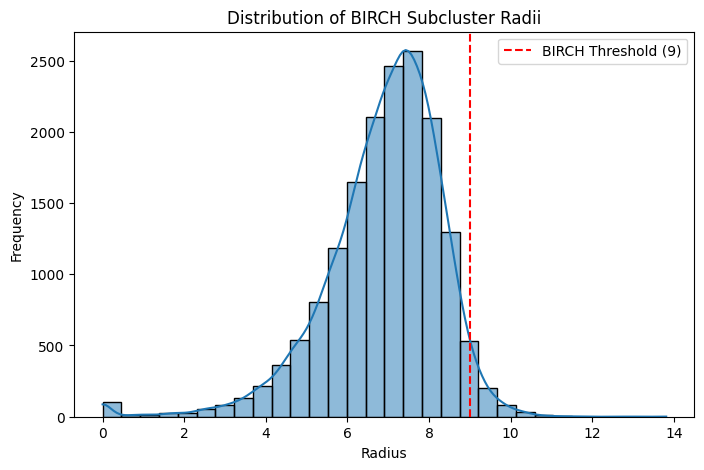

In [19]:
# Subcluster centroids
subcluster_centers = brc.subcluster_centers_
print(f"Number of BIRCH subclusters: {len(subcluster_centers)}")
radii = []
sizes = []

for i in tqdm(range(len(subcluster_centers))):
    idx = np.where(labels == i)[0]
    if len(idx) == 0:
        continue
    diff = X_scaled[idx] - subcluster_centers[i]
    radius = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
    radii.append(radius)
    sizes.append(len(idx))

radii = np.array(radii)
sizes = np.array(sizes)

print("Look at radius distribution that should be below the threshold (0.7):")
print(radii.min(), radii.mean(), radii.max())

plt.figure(figsize=(8, 5))
sns.histplot(radii, bins=30, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'BIRCH Threshold ({threshold})')
plt.title('Distribution of BIRCH Subcluster Radii')
plt.xlabel('Radius')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(out / "birch_subcluster_radii_distribution.png")
plt.show()


In [20]:
# agg = AgglomerativeClustering(
#     metric='euclidean',
#     distance_threshold=distance,          # or use distance_threshold
#     n_clusters=None,
#     linkage="ward"
# )

# subcluster_labels = agg.fit_predict(subcluster_centers)
# final_labels = subcluster_labels[brc.labels_]


In [21]:
linkage_matrix = linkage(subcluster_centers, method='ward', metric='euclidean')


In [22]:
pd.DataFrame(linkage_matrix, columns=["cluster1", "cluster2", "distance", "n_points"]).to_csv(out / "birch_subcluster_linkage_matrix.csv", index=False)

In [3]:
linkage_matrix = pd.read_csv(out / "birch_subcluster_linkage_matrix.csv").to_numpy()

In [4]:
merge_distances = linkage_matrix[:, 2]

print(
    merge_distances.min(),
    merge_distances.mean(),
    merge_distances.max()
)

d = merge_distances
for p in [90, 95, 97, 98, 99]:
    print(p, np.percentile(d, p))

1.3472631016253045 15.261215529282346 1025.112525999643
90 24.951523156199155
95 34.36452167271611
97 43.65176338351306
98 53.41043722108803
99 76.4139950644205


In [6]:
distance = 75  # conservative will be 28. coarse will be 98 and 40 for moderate

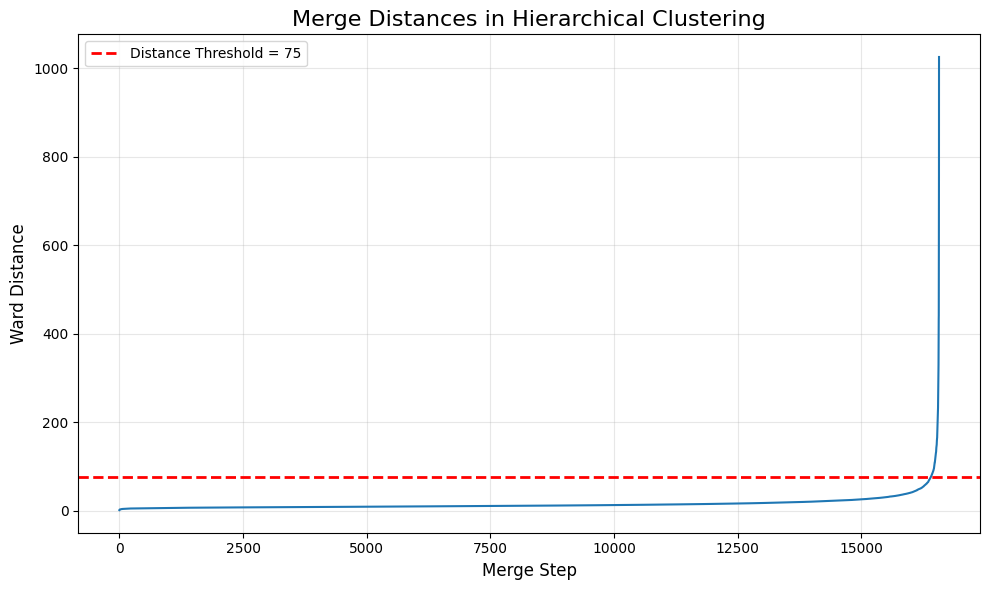

In [25]:
plt.figure(figsize=(10, 6))
sns.lineplot(merge_distances)
plt.axhline(y=distance, color='r', linestyle='--', linewidth=2, label=f'Distance Threshold = {distance}')
plt.title('Merge Distances in Hierarchical Clustering', fontsize=16)
plt.xlabel('Merge Step', fontsize=12)
plt.ylabel('Ward Distance', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(out / "hierarchical_clustering_merge_distances.png")
plt.show()

In [ ]:
dmesure = pd.DataFrame()
for d in [60,65,70,75,80,85,90,95]:
    labels2 = fcluster(linkage_matrix, t=d, criterion="distance")
    dmesure = pd.concat([dmesure, pd.DataFrame([{
        "distance_threshold": d,
        "silhouette_score": silhouette_score(subcluster_centers, labels2),
        "davies_bouldin_index": davies_bouldin_score(subcluster_centers, labels2),
        "calinski_harabasz_score": calinski_harabasz_score(subcluster_centers, labels2)
    }])], ignore_index=True)

dmesure.to_csv(out / "clustering_quality_metrics_distance_thresholds.csv", index=False)


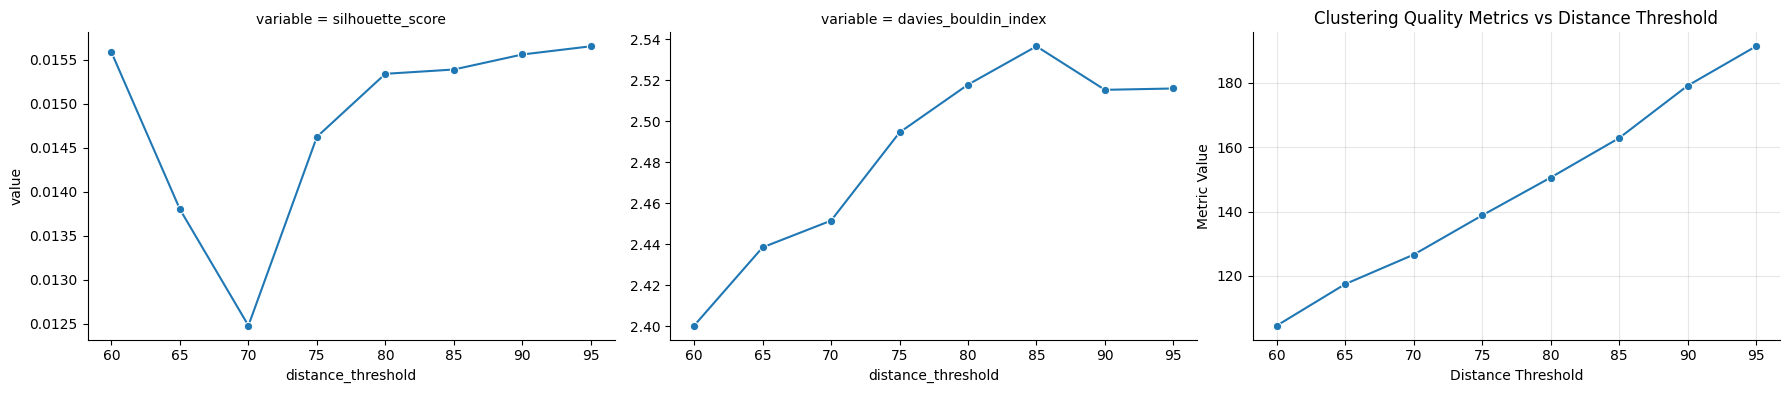

In [27]:
g = sns.FacetGrid(dmesure.melt(id_vars="distance_threshold"), col="variable", sharey=False, height=4, aspect=1.5)
g.map(sns.lineplot, "distance_threshold", "value", marker="o")
plt.title("Clustering Quality Metrics vs Distance Threshold")
plt.xlabel("Distance Threshold")
plt.ylabel("Metric Value")
plt.grid(True, alpha=0.3)
plt.savefig(out / "clustering_quality_metrics_vs_distance_threshold.png")
plt.show()

In [31]:
birch_labels = labels.numpy()
birch_labels_test = labels_test.numpy()

In [32]:
label_sub = fcluster(linkage_matrix, t=distance, criterion='distance')
scipy_final = label_sub[birch_labels]
scipy_finale_test = label_sub[birch_labels_test]

# save
pd.DataFrame(scipy_final, columns=["cluster_id"]).to_csv(out / "train_hierarchical_cluster_labels.csv", index=False)
pd.DataFrame(scipy_finale_test, columns=["cluster_id"]).to_csv(out / "test_hierarchical_cluster_labels.csv", index=False)


# Alternative: Dendrogram with distance threshold line
# plt.figure(figsize=(20, 10))
# dend = dendrogram(
#     linkage_matrix,
#     truncate_mode='lastp',
#     p=50,
#     leaf_font_size=10,
#     show_leaf_counts=True,
#     color_threshold=1.5  # Same as the distance_threshold used in AgglomerativeClustering
# )
# plt.axhline(y=1.5, color='r', linestyle='--', linewidth=2, label=f'Distance Threshold = {distance}')
# plt.title('Dendrogram with Distance Threshold', fontsize=16)
# plt.xlabel('Subcluster Index (or Number of Points)', fontsize=12)
# plt.ylabel('Ward Distance', fontsize=12)
# plt.legend()
# plt.grid(True, alpha=0.3, axis='y')
# plt.tight_layout()
# plt.show()





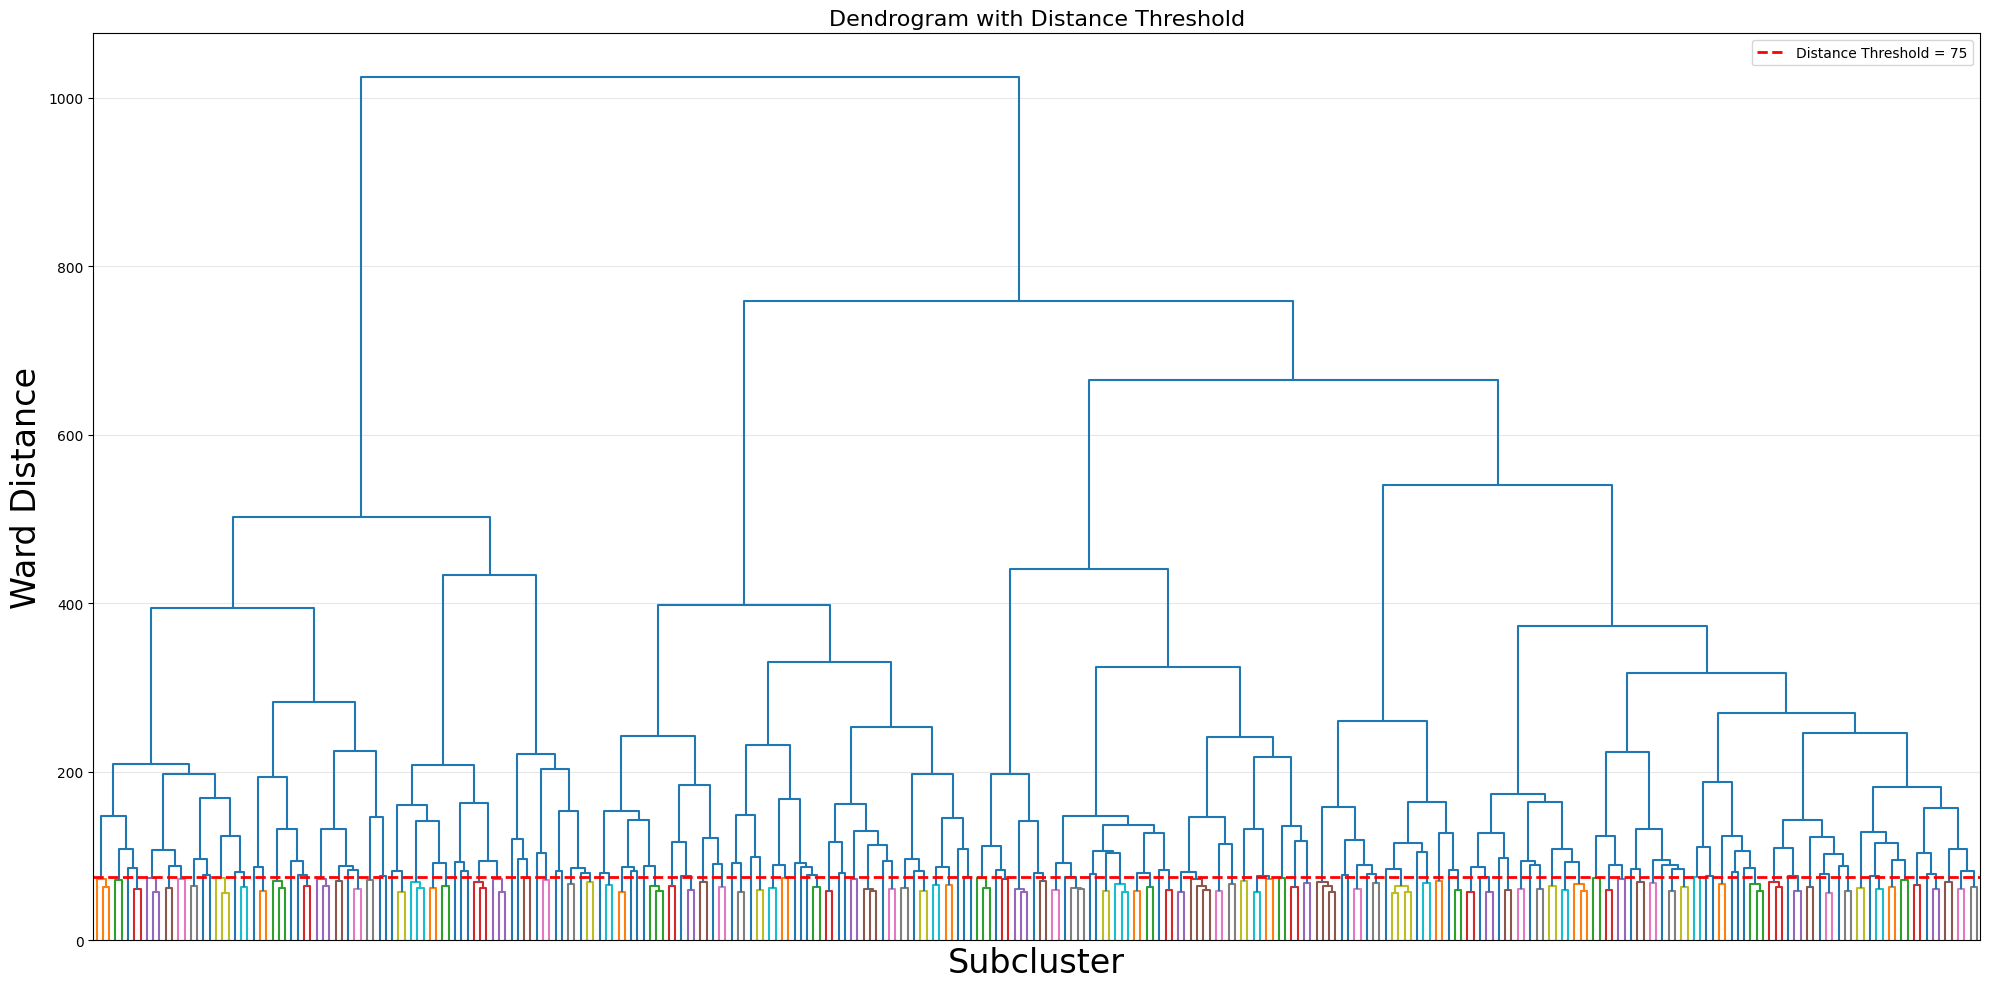

In [16]:
# Alternative: Dendrogram with distance threshold line
plt.figure(figsize=(20, 10))
dend = dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=300,
    leaf_font_size=10,
    show_leaf_counts=True,
    color_threshold=distance  # Same as the distance_threshold used in AgglomerativeClustering
)
plt.axhline(y=distance, color='r', linestyle='--', linewidth=2, label=f'Distance Threshold = {distance}')
plt.title('Dendrogram with Distance Threshold', fontsize=16)
plt.xlabel('Subcluster', fontsize=24)
plt.ylabel('Ward Distance', fontsize=24)
plt.xticks([])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(out / "dendrogram_with_distance_threshold.png")
plt.show()

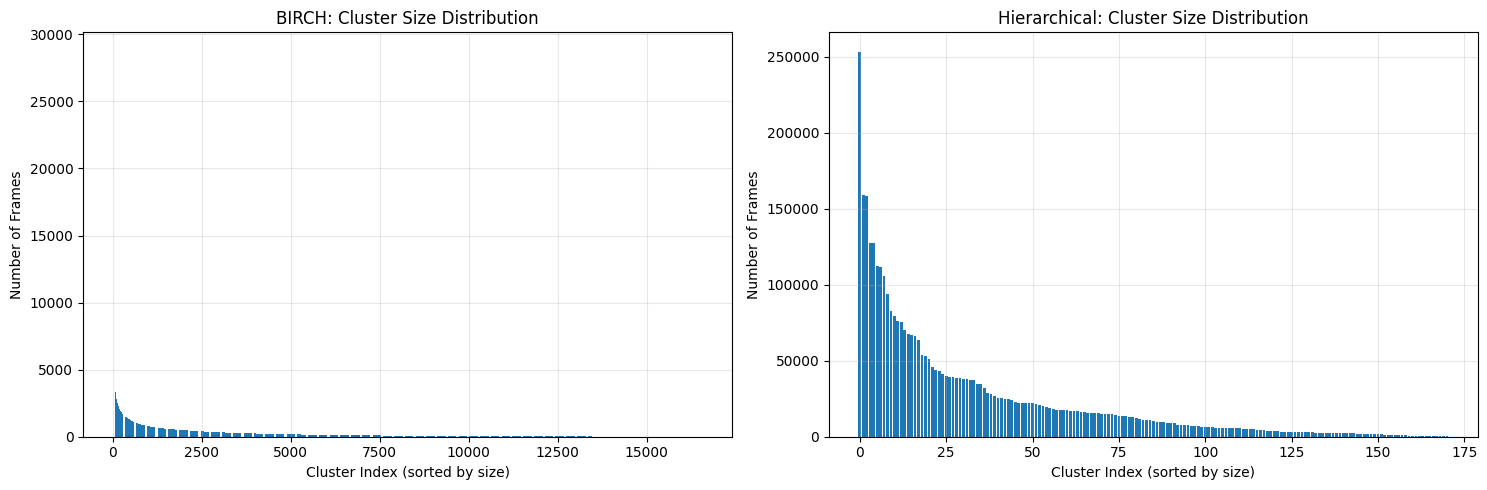

In [33]:
# Visualize cluster size distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# BIRCH cluster sizes
unique_birch, counts_birch = np.unique(labels, return_counts=True)
axes[0].bar(range(len(counts_birch)), sorted(counts_birch, reverse=True))
axes[0].set_title('BIRCH: Cluster Size Distribution')
axes[0].set_xlabel('Cluster Index (sorted by size)')
axes[0].set_ylabel('Number of Frames')
axes[0].grid(True, alpha=0.3)

# Hierarchical cluster sizes
unique_hier, counts_hier = np.unique(scipy_final, return_counts=True)
axes[1].bar(range(len(counts_hier)), sorted(counts_hier, reverse=True))
axes[1].set_title('Hierarchical: Cluster Size Distribution')
axes[1].set_xlabel('Cluster Index (sorted by size)')
axes[1].set_ylabel('Number of Frames')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out / "cluster_size_distributions.png")
plt.show()

In [34]:
dmetrics = pd.DataFrame()

birch_silhouette_test = silhouette_score(subcluster_centers, label_sub)
birch_db_test = davies_bouldin_score(subcluster_centers, label_sub)
birch_ch_test = calinski_harabasz_score(subcluster_centers, label_sub)
dmetrics = pd.concat([dmetrics, pd.DataFrame([{
    "silhouette_score": birch_silhouette_test,
    "davies_bouldin_index": birch_db_test,
    "calinski_harabasz_score": birch_ch_test
}])], ignore_index=True)

dmetrics.to_csv(out / "clustering_quality_metrics_test.csv", index=False)

In [36]:
scipy_final

array([ 71,  74, 111, ...,  93,  93,  93], shape=(3881230,), dtype=int32)

In [38]:
df['cluster_id'] = scipy_final
df_test['cluster_id'] = scipy_finale_test

In [40]:
df.head()

,index,0,1,2,3,4,5,6,7,8,...,249,250,251,252,253,254,255,segment_name,segment_id,cluster_id
0,0,2.912275,-1.586671,-0.563191,1.953273,-1.504419,0.232358,2.862194,-0.084604,-0.869344,...,-0.646760,0.273038,0.833634,-0.283195,-0.529068,-0.116389,1.688021,8449_seg04,0,71
1,1,2.813429,-1.609902,-0.637321,1.957148,-1.342056,0.298692,2.730185,-0.015838,-0.747254,...,-0.507493,0.401676,1.041322,-0.443057,-0.573150,-0.137157,1.682798,8449_seg04,0,74
2,2,1.392535,-1.999742,-0.025286,1.142155,-0.561598,0.914643,3.710985,-0.048691,-0.969110,...,-0.089485,0.696023,2.622499,-0.929614,-0.787865,-0.317302,1.856823,8449_seg04,0,111
3,3,1.000328,-1.811827,0.091461,1.063048,-0.335328,0.953911,3.788075,0.077083,-0.924319,...,-0.013091,0.413179,3.142873,-1.000264,-0.927722,-0.262966,2.004759,8449_seg04,0,111
4,4,0.744612,-0.718734,0.119135,1.128807,-0.336165,0.708012,3.545437,0.117203,-0.915370,...,-0.059483,0.212437,3.883486,-0.997011,-0.915403,0.021915,2.205127,8449_seg04,0,111


In [41]:
df[['index', 'segment_name', 'segment_id', 'cluster_id']].to_csv(out / "mapping_cluster_frame_train.csv", index=False)
df_test[['index', 'segment_name', 'segment_id', 'cluster_id']].to_csv(out / "mapping_cluster_frame_test.csv", index=False)

## Temporal Coherence Analysis

Analyze how stable cluster assignments are over time. Good behavior clusters should form continuous bouts, not flicker between states.

In [127]:
def compute_temporal_coherence(labels, segment_boundaries):
    """
    Compute temporal coherence metrics for cluster assignments.
    
    Parameters:
    -----------
    labels : np.ndarray
        Cluster labels for each frame
    segment_boundaries : list of tuples
        [(start_idx, end_idx), ...] for each video segment
        
    Returns:
    --------
    dict with metrics:
        - mean_bout_length: average number of consecutive frames in same cluster
        - switch_rate: proportion of frames where cluster changes
        - stability_score: 1 - switch_rate (higher = more stable)
    """
    switches = 0
    bout_lengths = []
    current_bout_length = 1
    
    for i in range(1, len(labels)):
        # Check if we're at a segment boundary
        at_boundary = any(i == end for start, end in segment_boundaries)
        
        if labels[i] != labels[i-1]:
            if not at_boundary:  # Don't count switches at segment boundaries
                switches += 1
            bout_lengths.append(current_bout_length)
            current_bout_length = 1
        else:
            current_bout_length += 1
    
    bout_lengths.append(current_bout_length)
    
    # Compute metrics per segment
    segment_metrics = []
    for seg_idx, (start, end) in enumerate(segment_boundaries):
        seg_labels = labels[start:end]
        seg_switches = np.sum(seg_labels[1:] != seg_labels[:-1])
        seg_switch_rate = seg_switches / (len(seg_labels) - 1) if len(seg_labels) > 1 else 0
        segment_metrics.append({
            'segment': seg_idx,
            'length': len(seg_labels),
            'switches': seg_switches,
            'switch_rate': seg_switch_rate,
            'stability': 1 - seg_switch_rate
        })
    
    total_valid_transitions = len(labels) - len(segment_boundaries)
    switch_rate = switches / total_valid_transitions if total_valid_transitions > 0 else 0
    
    return {
        'mean_bout_length': np.mean(bout_lengths),
        'median_bout_length': np.median(bout_lengths),
        'std_bout_length': np.std(bout_lengths),
        'switch_rate': switch_rate,
        'stability_score': 1 - switch_rate,
        'total_bouts': len(bout_lengths),
        'segment_metrics': pd.DataFrame(segment_metrics)
    }

In [128]:
dsave = pd.DataFrame()

# Build segment boundaries
segment_boundaries = []
cumsum = 0
for seg in segs_smoothed:
    start = cumsum
    end = cumsum + len(seg)
    segment_boundaries.append((start, end))
    cumsum = end

print(f"Number of segments: {len(segment_boundaries)}")
print(f"Total frames: {cumsum}")

# Compute temporal coherence for both clustering methods
print("\n" + "=" * 70)
print("TEMPORAL COHERENCE ANALYSIS")
print("=" * 70)

birch_coherence = compute_temporal_coherence(scipy_finale_test, segment_boundaries)
dsave = dsave.append({
    "set": "test",
    "mean_bout_length": birch_coherence['mean_bout_length'],
    "median_bout_length": birch_coherence['median_bout_length'],
    "std_bout_length": birch_coherence['std_bout_length'],
    "switch_rate": birch_coherence['switch_rate'],
    "stability_score": birch_coherence['stability_score'],
    "total_bouts": birch_coherence['total_bouts']
}, ignore_index=True)

hier_coherence = compute_temporal_coherence(scipy_final, segment_boundaries)
dsave = dsave.append({
    "set": "train",
    "mean_bout_length": hier_coherence['mean_bout_length'],
    "median_bout_length": hier_coherence['median_bout_length'],
    "std_bout_length": hier_coherence['std_bout_length'],
    "switch_rate": hier_coherence['switch_rate'],
    "stability_score": hier_coherence['stability_score'],
    "total_bouts": hier_coherence['total_bouts']
}, ignore_index=True)

print("\n### BIRCH Clustering Temporal Coherence:")
print(f"  Mean bout length: {birch_coherence['mean_bout_length']:.2f} frames ({birch_coherence['mean_bout_length']/20:.2f} seconds @ 20fps)")
print(f"  Median bout length: {birch_coherence['median_bout_length']:.2f} frames")
print(f"  Std bout length: {birch_coherence['std_bout_length']:.2f} frames")
print(f"  Switch rate: {birch_coherence['switch_rate']:.4f} (cluster changes per frame)")
print(f"  Stability score: {birch_coherence['stability_score']:.4f} (higher = more stable)")
print(f"  Total behavior bouts: {birch_coherence['total_bouts']}")

print("\n### Hierarchical Clustering Temporal Coherence:")
print(f"  Mean bout length: {hier_coherence['mean_bout_length']:.2f} frames ({hier_coherence['mean_bout_length']/20:.2f} seconds @ 20fps)")
print(f"  Median bout length: {hier_coherence['median_bout_length']:.2f} frames")
print(f"  Std bout length: {hier_coherence['std_bout_length']:.2f} frames")
print(f"  Switch rate: {hier_coherence['switch_rate']:.4f} (cluster changes per frame)")
print(f"  Stability score: {hier_coherence['stability_score']:.4f} (higher = more stable)")
print(f"  Total behavior bouts: {hier_coherence['total_bouts']}")

print("\n### Interpretation:")
print(f"  With LISBET's 1000-frame window (~50 seconds @ 20fps),")
print(f"  we expect behaviors to span at least several seconds (40-100+ frames).")
if hier_coherence['mean_bout_length'] < 40:
    print(f"  ⚠️ WARNING: Mean bout length is very short - clusters may be too fragmented!")
elif hier_coherence['mean_bout_length'] > 100:
    print(f"  ✓ Good: Clusters form substantial bouts consistent with behavior timescales.")
else:
    print(f"  Moderate: Bout lengths in reasonable range, but check if behaviors are truly discrete.")

NameError: name 'segs_smoothed' is not defined

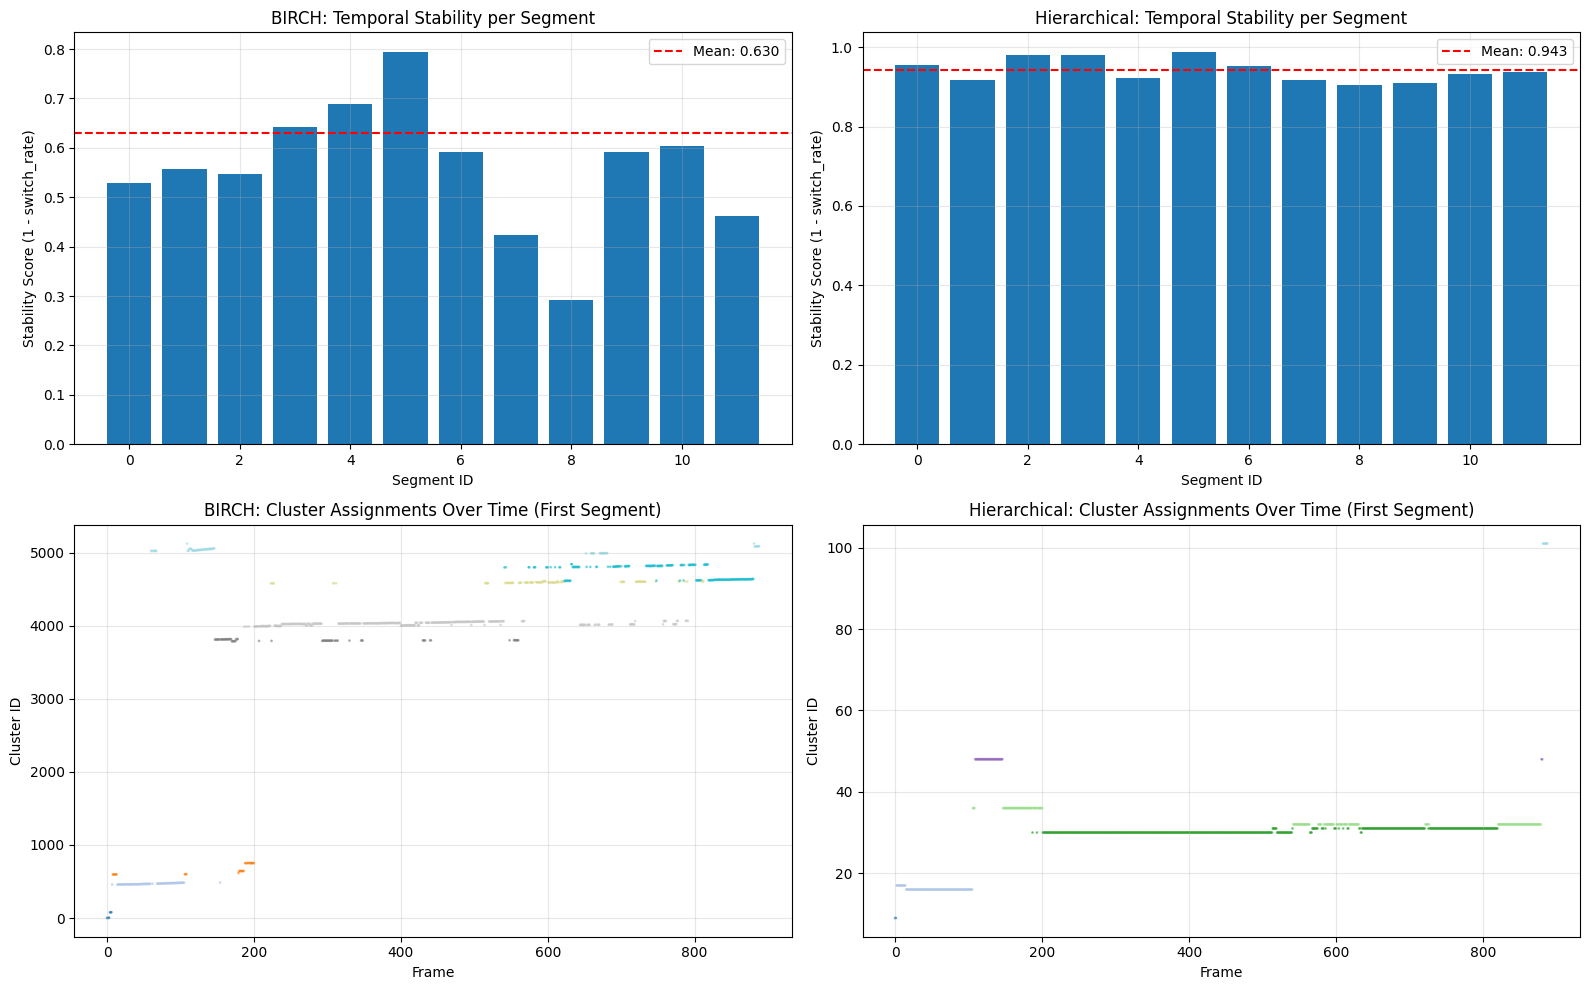

In [ ]:
# Visualize temporal coherence per segment
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Per-segment stability scores
axes[0, 0].bar(birch_coherence['segment_metrics']['segment'], 
               birch_coherence['segment_metrics']['stability'])
axes[0, 0].set_title('BIRCH: Temporal Stability per Segment')
axes[0, 0].set_xlabel('Segment ID')
axes[0, 0].set_ylabel('Stability Score (1 - switch_rate)')
axes[0, 0].axhline(y=birch_coherence['stability_score'], color='r', linestyle='--', 
                   label=f'Mean: {birch_coherence["stability_score"]:.3f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].bar(hier_coherence['segment_metrics']['segment'], 
               hier_coherence['segment_metrics']['stability'])
axes[0, 1].set_title('Hierarchical: Temporal Stability per Segment')
axes[0, 1].set_xlabel('Segment ID')
axes[0, 1].set_ylabel('Stability Score (1 - switch_rate)')
axes[0, 1].axhline(y=hier_coherence['stability_score'], color='r', linestyle='--',
                   label=f'Mean: {hier_coherence["stability_score"]:.3f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Visualize cluster assignments over time for first segment
first_seg_len = segment_boundaries[0][1] - segment_boundaries[0][0]
sample_frames = min(1000, first_seg_len)  # Show first 1000 frames or full segment

axes[1, 0].scatter(range(sample_frames), birch_labels[:sample_frames], 
                   alpha=0.5, s=1, c=birch_labels[:sample_frames], cmap='tab20')
axes[1, 0].set_title('BIRCH: Cluster Assignments Over Time (First Segment)')
axes[1, 0].set_xlabel('Frame')
axes[1, 0].set_ylabel('Cluster ID')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(range(sample_frames), scipy_final[:sample_frames], 
                   alpha=0.5, s=1, c=scipy_final[:sample_frames], cmap='tab20')
axes[1, 1].set_title('Hierarchical: Cluster Assignments Over Time (First Segment)')
axes[1, 1].set_xlabel('Frame')
axes[1, 1].set_ylabel('Cluster ID')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out / "temporal_coherence_analysis.png")
plt.show()

## Cross-Video Cluster Validation

Validate that clusters represent shared behaviors across multiple video segments. Good behavior clusters should appear in many videos, not be segment-specific.

In [ ]:
def analyze_cross_video_clusters(labels, segment_boundaries):
    """
    Analyze how clusters are distributed across video segments.
    
    Returns:
    --------
    dict with:
        - cluster_segment_matrix: binary matrix [n_clusters x n_segments] showing presence
        - cluster_prevalence: how many segments each cluster appears in
        - segment_diversity: how many unique clusters each segment contains
    """
    n_segments = len(segment_boundaries)
    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)
    
    # Build cluster-segment presence matrix
    cluster_segment_matrix = np.zeros((n_clusters, n_segments), dtype=int)
    
    segment_info = []
    for seg_idx, (start, end) in enumerate(segment_boundaries):
        seg_labels = labels[start:end]
        unique_in_seg = np.unique(seg_labels)
        
        for cluster_id in unique_in_seg:
            cluster_idx = np.where(unique_clusters == cluster_id)[0][0]
            cluster_segment_matrix[cluster_idx, seg_idx] = 1
        
        # Compute statistics for this segment
        cluster_counts = pd.Series(seg_labels).value_counts()
        segment_info.append({
            'segment': seg_idx,
            'n_frames': len(seg_labels),
            'n_unique_clusters': len(unique_in_seg),
            'most_common_cluster': cluster_counts.index[0],
            'most_common_count': cluster_counts.iloc[0],
            'most_common_pct': cluster_counts.iloc[0] / len(seg_labels) * 100
        })
    
    # Cluster prevalence (how many segments each cluster appears in)
    cluster_prevalence = cluster_segment_matrix.sum(axis=1)
    
    # Segment diversity (how many unique clusters per segment)
    segment_diversity = cluster_segment_matrix.sum(axis=0)
    
    return {
        'cluster_segment_matrix': cluster_segment_matrix,
        'cluster_prevalence': cluster_prevalence,
        'segment_diversity': segment_diversity,
        'unique_clusters': unique_clusters,
        'segment_info': pd.DataFrame(segment_info)
    }

In [ ]:
# Analyze cross-video cluster distribution
print("=" * 70)
print("CROSS-VIDEO CLUSTER VALIDATION")
print("=" * 70)

birch_cross = analyze_cross_video_clusters(birch_labels, segment_boundaries)
hier_cross = analyze_cross_video_clusters(scipy_final, segment_boundaries)

print(f"\n### BIRCH Clustering:")
print(f"  Total clusters: {len(birch_cross['unique_clusters'])}")
print(f"  Total segments: {len(segment_boundaries)}")
print(f"  Mean clusters per segment: {birch_cross['segment_diversity'].mean():.1f}")
print(f"  Mean segments per cluster: {birch_cross['cluster_prevalence'].mean():.1f}")

# Check for segment-specific clusters (red flag)
segment_specific = (birch_cross['cluster_prevalence'] == 1).sum()
widespread = (birch_cross['cluster_prevalence'] >= len(segment_boundaries) * 0.5).sum()
print(f"  Segment-specific clusters (appear in only 1 video): {segment_specific} ({segment_specific/len(birch_cross['unique_clusters'])*100:.1f}%)")
print(f"  Widespread clusters (appear in ≥50% of videos): {widespread} ({widespread/len(birch_cross['unique_clusters'])*100:.1f}%)")

print(f"\n### Hierarchical Clustering:")
print(f"  Total clusters: {len(hier_cross['unique_clusters'])}")
print(f"  Total segments: {len(segment_boundaries)}")
print(f"  Mean clusters per segment: {hier_cross['segment_diversity'].mean():.1f}")
print(f"  Mean segments per cluster: {hier_cross['cluster_prevalence'].mean():.1f}")

segment_specific_h = (hier_cross['cluster_prevalence'] == 1).sum()
widespread_h = (hier_cross['cluster_prevalence'] >= len(segment_boundaries) * 0.5).sum()
print(f"  Segment-specific clusters (appear in only 1 video): {segment_specific_h} ({segment_specific_h/len(hier_cross['unique_clusters'])*100:.1f}%)")
print(f"  Widespread clusters (appear in ≥50% of videos): {widespread_h} ({widespread_h/len(hier_cross['unique_clusters'])*100:.1f}%)")

print("\n### Interpretation:")
if segment_specific_h > len(hier_cross['unique_clusters']) * 0.3:
    print("  ⚠️ WARNING: >30% of clusters are segment-specific - may indicate overfitting!")
    print("  Consider: more regularization, fewer clusters, or better video alignment.")
elif widespread_h < len(hier_cross['unique_clusters']) * 0.2:
    print("  ⚠️ WARNING: <20% of clusters are widespread - behaviors may not generalize!")
else:
    print("  ✓ Good: Reasonable balance of shared behaviors across videos.")

CROSS-VIDEO CLUSTER VALIDATION

### BIRCH Clustering:
  Total clusters: 5214
  Total segments: 12
  Mean clusters per segment: 434.5
  Mean segments per cluster: 1.0
  Segment-specific clusters (appear in only 1 video): 5214 (100.0%)
  Widespread clusters (appear in ≥50% of videos): 0 (0.0%)

### Hierarchical Clustering:
  Total clusters: 113
  Total segments: 12
  Mean clusters per segment: 13.6
  Mean segments per cluster: 1.4
  Segment-specific clusters (appear in only 1 video): 83 (73.5%)
  Widespread clusters (appear in ≥50% of videos): 1 (0.9%)

### Interpretation:
  ⚠️ WARNING: >30% of clusters are segment-specific - may indicate overfitting!
  Consider: more regularization, fewer clusters, or better video alignment.


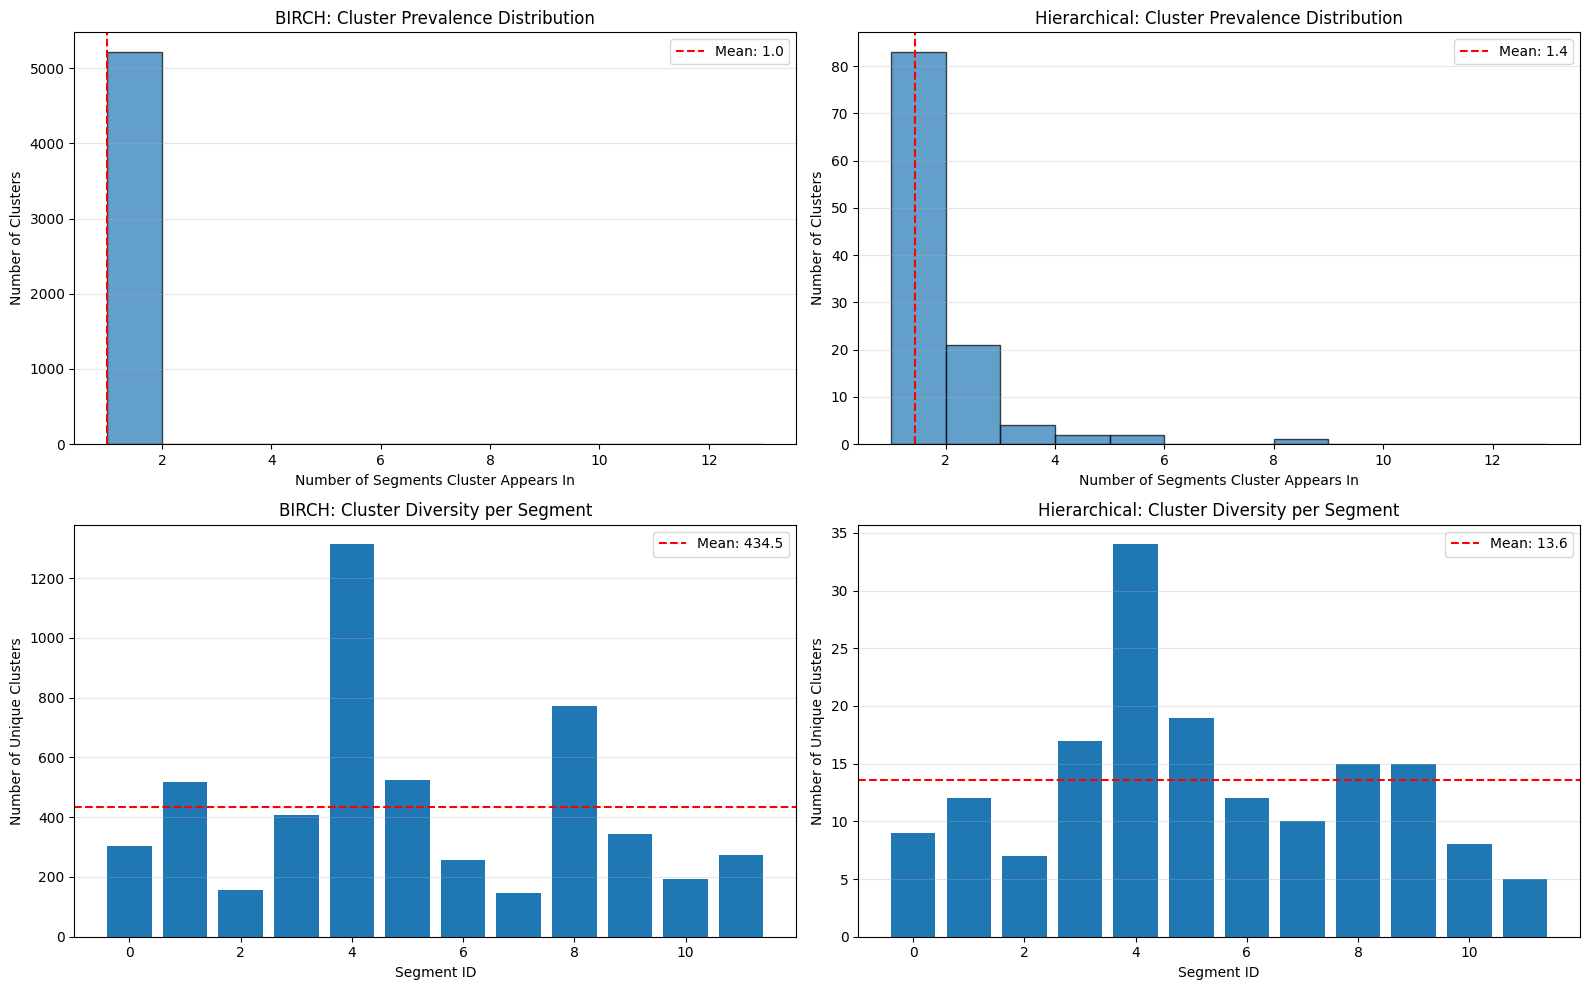

In [ ]:
# Visualize cross-video cluster distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cluster prevalence (how many segments each cluster appears in)
axes[0, 0].hist(birch_cross['cluster_prevalence'], bins=range(1, len(segment_boundaries)+2), 
                edgecolor='black', alpha=0.7)
axes[0, 0].set_title('BIRCH: Cluster Prevalence Distribution')
axes[0, 0].set_xlabel('Number of Segments Cluster Appears In')
axes[0, 0].set_ylabel('Number of Clusters')
axes[0, 0].axvline(x=birch_cross['cluster_prevalence'].mean(), color='r', linestyle='--',
                   label=f'Mean: {birch_cross["cluster_prevalence"].mean():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].hist(hier_cross['cluster_prevalence'], bins=range(1, len(segment_boundaries)+2), 
                edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Hierarchical: Cluster Prevalence Distribution')
axes[0, 1].set_xlabel('Number of Segments Cluster Appears In')
axes[0, 1].set_ylabel('Number of Clusters')
axes[0, 1].axvline(x=hier_cross['cluster_prevalence'].mean(), color='r', linestyle='--',
                   label=f'Mean: {hier_cross["cluster_prevalence"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Segment diversity (how many unique clusters per segment)
axes[1, 0].bar(range(len(segment_boundaries)), birch_cross['segment_diversity'])
axes[1, 0].set_title('BIRCH: Cluster Diversity per Segment')
axes[1, 0].set_xlabel('Segment ID')
axes[1, 0].set_ylabel('Number of Unique Clusters')
axes[1, 0].axhline(y=birch_cross['segment_diversity'].mean(), color='r', linestyle='--',
                   label=f'Mean: {birch_cross["segment_diversity"].mean():.1f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(range(len(segment_boundaries)), hier_cross['segment_diversity'])
axes[1, 1].set_title('Hierarchical: Cluster Diversity per Segment')
axes[1, 1].set_xlabel('Segment ID')
axes[1, 1].set_ylabel('Number of Unique Clusters')
axes[1, 1].axhline(y=hier_cross['segment_diversity'].mean(), color='r', linestyle='--',
                   label=f'Mean: {hier_cross["segment_diversity"].mean():.1f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(out / "cross_video_cluster_distribution.png")
plt.show()

In [ ]:
# Heatmap of cluster-segment co-occurrence (for hierarchical only, if manageable size)
if len(hier_cross['unique_clusters']) <= 50:  # Only plot if not too many clusters
    plt.figure(figsize=(16, 10))
    sns.heatmap(hier_cross['cluster_segment_matrix'], 
                cmap='YlOrRd', 
                cbar_kws={'label': 'Presence'},
                xticklabels=range(len(segment_boundaries)),
                yticklabels=hier_cross['unique_clusters'])
    plt.title('Hierarchical: Cluster-Segment Co-occurrence Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Segment ID', fontsize=12)
    plt.ylabel('Cluster ID', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"\nSkipping heatmap: too many clusters ({len(hier_cross['unique_clusters'])}) to visualize effectively.")
    print(f"Consider filtering to show only the most prevalent clusters.")


Skipping heatmap: too many clusters (113) to visualize effectively.
Consider filtering to show only the most prevalent clusters.
